In [35]:
import os
import math
import json
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





RANDOM_STATE = 42
DATA_PATH = "Dataset_Ads.csv"
assert os.path.exists(DATA_PATH), f"Dataset not found: {DATA_PATH}"
df = pd.read_csv(DATA_PATH)
print("Loaded:", df.shape)
print("Columns:", list(df.columns))
display(df.head())


Loaded: (10000, 11)
Columns: ['Age', 'Gender', 'Income', 'Location', 'Ad Type', 'Ad Topic', 'Ad Placement', 'Clicks', 'Click Time', 'Conversion Rate', 'CTR']


,Age,Gender,Income,Location,Ad Type,Ad Topic,Ad Placement,Clicks,Click Time,Conversion Rate,CTR
0,61,Male,35717.43,Urban,Banner,Travel,Social Media,3,2024-01-18 20:45:56.898459,0.0981,0.0737
1,41,Male,47453.25,Rural,Video,Travel,Search Engine,5,2023-04-24 20:45:56.898459,0.0937,0.0592
2,49,Female,68126.35,Rural,Text,Food,Social Media,4,2024-02-24 20:45:56.898459,0.1912,0.0563
3,68,Female,64585.73,Suburban,Text,Health,Website,6,2023-12-13 20:45:56.898459,0.1122,0.0232
4,63,Male,21109.40,Urban,Native,Fashion,Search Engine,5,2023-07-02 20:45:56.898459,0.1426,0.0539


In [36]:

def find_col(candidates, columns):
    cols_lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    for cand in candidates:
        for c in columns:
            if cand.lower() in c.lower():
                return c
    return None

col_ctr = find_col(["CTR", "click_through_rate", "clickthroughrate"], df.columns)
col_conv = find_col(["Conversion Rate", "conversion_rate", "ConversionRate"], df.columns)
col_clicks = find_col(["Clicks", "clicks"], df.columns)
col_timestamp = find_col(["Timestamp", "time", "datetime", "date"], df.columns)
col_placement = find_col(["Ad Placement", "placement", "ad_placement"], df.columns)
col_gender = find_col(["Gender", "sex"], df.columns)
col_location = find_col(["Location", "country", "region", "city"], df.columns)

print("\nDetected key columns:")
print("CTR:", col_ctr)
print("Conversion Rate:", col_conv)
print("Clicks:", col_clicks)
print("Timestamp:", col_timestamp)
print("Ad Placement:", col_placement)
print("Gender:", col_gender)
print("Location:", col_location)


Detected key columns:
CTR: CTR
Conversion Rate: Conversion Rate
Clicks: Clicks
Timestamp: Click Time
Ad Placement: Ad Placement
Gender: Gender
Location: Location


In [42]:
df_clean = df.copy()

for c in df_clean.select_dtypes(include=["object"]).columns:
    df_clean[c] = df_clean[c].astype(str).str.strip()


df_clean[col_ctr] = pd.to_numeric(df_clean[col_ctr], errors="coerce")
df_clean[col_conv] = pd.to_numeric(df_clean[col_conv], errors="coerce")
if col_clicks is not None:
    df_clean[col_clicks] = pd.to_numeric(df_clean[col_clicks], errors="coerce")


def add_time_features(df_in, ts_col):
    df_out = df_in.copy()

    if ts_col is None or ts_col not in df_out.columns:
        return df_out

    ts = pd.to_datetime(df_out[ts_col], errors="coerce")

    df_out["hour"] = ts.dt.hour
    df_out["dayofweek"] = ts.dt.dayofweek   # 0 = Monday
    df_out["month"] = ts.dt.month
    df_out["is_weekend"] = (ts.dt.dayofweek >= 5).astype(float)

    df_out = df_out.drop(columns=[ts_col])

    return df_out


df_clean = add_time_features(df_clean, col_timestamp)


def normalize_rate(series):
    s = series.replace([np.inf, -np.inf], np.nan).astype(float)
    mx = np.nanmax(s.values) if np.any(~np.isnan(s.values)) else np.nan
    if not np.isnan(mx) and mx > 1.5:  # looks like percent
        s = s / 100.0
    return s

df_clean[col_ctr] = normalize_rate(df_clean[col_ctr]).clip(0, 1)
df_clean[col_conv] = normalize_rate(df_clean[col_conv]).clip(0, 1)


df_clean = df_clean.dropna(subset=[col_ctr, col_conv]).reset_index(drop=True)


df_clean["expected_conv_per_impression"] = (df_clean[col_ctr] * df_clean[col_conv]).clip(0, 1)

print("\nAfter cleaning:", df_clean.shape)
display(df_clean.describe(include="all").transpose().head(25))




print("VARIABLE TYPES: Continuous vs Discrete")


variable_types = {
    "Age":                           "Discrete  (integer counts of years)",
    "Gender":                        "Discrete  (categorical: Male / Female / Other)",
    "Income":                        "Continuous (real-valued, any positive amount)",
    "Location":                      "Discrete  (categorical: Urban / Suburban / Rural)",
    "Ad Type":                       "Discrete  (categorical: Banner / Video / Text / Native)",
    "Ad Topic":                      "Discrete  (categorical: Travel / Food / Health / …)",
    "Ad Placement":                  "Discrete  (categorical: Social Media / Search Engine / Website)",
    "Clicks":                        "Discrete  (non-negative integer count of clicks)",
    "Conversion Rate":               "Continuous (ratio in [0, 1], real-valued)",
    "CTR":                           "Continuous (ratio in [0, 1], real-valued)",
    "expected_conv_per_impression":  "Continuous (derived ratio CTR × Conversion Rate, real-valued)",
    "hour":                          "Discrete  (integer 0-23, extracted from timestamp)",
    "dayofweek":                     "Discrete  (integer 0-6, Monday=0)",
    "month":                         "Discrete  (integer 1-12)",
    "is_weekend":                    "Discrete  (binary flag: 0 or 1)",
}

for col, vtype in variable_types.items():
    print(f"  {col:<35} → {vtype}")




After cleaning: (10000, 15)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,10000.0,NaN,NaN,NaN,34.2352,14.790752,-21.0,24.0,34.0,44.0,92.0
Gender,10000,3,Male,4986,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,10000.0,NaN,NaN,NaN,50080.040922,19935.832667,-38932.64,36892.04,50122.52,63271.3425,126635.8
Location,10000,3,Rural,3408,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ad Type,10000,4,Banner,2560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ad Topic,10000,6,Finance,1734,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ad Placement,10000,3,Social Media,3340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Clicks,10000.0,NaN,NaN,NaN,5.0306,2.258046,0.0,3.0,5.0,6.0,17.0
Conversion Rate,10000.0,NaN,NaN,NaN,0.202246,0.121094,0.001,0.1095,0.18065,0.2751,0.7317
CTR,10000.0,NaN,NaN,NaN,0.050425,0.019821,0.0,0.0371,0.0503,0.0637,0.1272


VARIABLE TYPES: Continuous vs Discrete
  Age                                 → Discrete  (integer counts of years)
  Gender                              → Discrete  (categorical: Male / Female / Other)
  Income                              → Continuous (real-valued, any positive amount)
  Location                            → Discrete  (categorical: Urban / Suburban / Rural)
  Ad Type                             → Discrete  (categorical: Banner / Video / Text / Native)
  Ad Topic                            → Discrete  (categorical: Travel / Food / Health / …)
  Ad Placement                        → Discrete  (categorical: Social Media / Search Engine / Website)
  Clicks                              → Discrete  (non-negative integer count of clicks)
  Conversion Rate                     → Continuous (ratio in [0, 1], real-valued)
  CTR                                 → Continuous (ratio in [0, 1], real-valued)
  expected_conv_per_impression        → Continuous (derived ratio CTR × Conve

In [43]:
import numpy as np
import pandas as pd
import plotly.express as px


ECPI = "expected_conv_per_impression"


def find_col_contains(candidates, columns):
    cols_lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    for cand in candidates:
        for c in columns:
            if cand.lower() in c.lower():
                return c
    return None

col_topic = find_col_contains(["Ad Topic", "Topic", "AdTopic"], df_clean.columns)
col_type  = find_col_contains(["Ad Type", "Type", "AdType"], df_clean.columns)
col_age   = find_col_contains(["Age"], df_clean.columns)
col_income= find_col_contains(["Income"], df_clean.columns)

print("Detected optional columns:")
print("Ad Topic:", col_topic)
print("Ad Type :", col_type)
print("Age     :", col_age)
print("Income  :", col_income)


dfp = df_clean.copy()


if col_age is not None and col_age in dfp.columns:
    age_num = pd.to_numeric(dfp[col_age], errors="coerce")
    dfp["AgeGroup"] = pd.cut(
        age_num,
        bins=[0, 29, 49, 200],
        labels=["Young", "Middle", "Elder"]
    )


if col_income is not None and col_income in dfp.columns:
    inc_num = pd.to_numeric(dfp[col_income], errors="coerce")
    
    try:
        dfp["IncomeGroup"] = pd.qcut(inc_num, q=3, labels=["Low", "Medium", "High"])
    except Exception:
        dfp["IncomeGroup"] = pd.cut(inc_num, bins=3, labels=["Low", "Medium", "High"])


if "hour" in dfp.columns:
    h = pd.to_numeric(dfp["hour"], errors="coerce")
    dfp["ClickTime"] = pd.cut(
        h,
        bins=[-1, 5, 11, 17, 23],
        labels=["Night", "Morning", "Afternoon", "Evening"]
    )


for c in [col_placement, col_topic, col_type, col_location, col_gender]:
    if c is not None and c in dfp.columns:
        dfp[c] = dfp[c].astype(str).str.strip()




def plot_mean_ecpi_by_category(df, cat_col, title, top_k=15, min_count=30, width=1000, height=420):
    if cat_col is None or cat_col not in df.columns:
        print(f"Skip {title}: column not found.")
        return

    tmp = df[[cat_col, ECPI]].dropna().copy()
    if tmp.empty:
        print(f"Skip {title}: no data.")
        return

    counts = tmp[cat_col].value_counts()
    keep = counts.head(top_k).index
    tmp = tmp[tmp[cat_col].isin(keep)].copy()

    grp = (
        tmp.groupby(cat_col)[ECPI]
           .agg(mean="mean", count="count")
           .reset_index()
    )
    grp = grp[grp["count"] >= min_count].sort_values("mean", ascending=False)
    if grp.empty:
        print(f"Skip {title}: no categories with count >= {min_count}. Try lowering min_count.")
        return

    fig = px.bar(
        grp,
        x=cat_col,
        y="mean",
        title=title,
        hover_data={"mean":":.6f", "count":True},
        text="mean"
    )
    fig.update_traces(texttemplate="%{text:.6f}", textposition="outside")
    fig.update_layout(width=width, height=height, xaxis_tickangle=-35,
                      yaxis_title="Mean ECPI")
    fig.update_traces(
        hovertemplate="<b>%{x}</b><br>Mean ECPI: %{y:.6f}<br>Count: %{customdata[1]}<extra></extra>"
    )
    fig.show()


Detected optional columns:
Ad Topic: Ad Topic
Ad Type : Ad Type
Age     : Age
Income  : Income


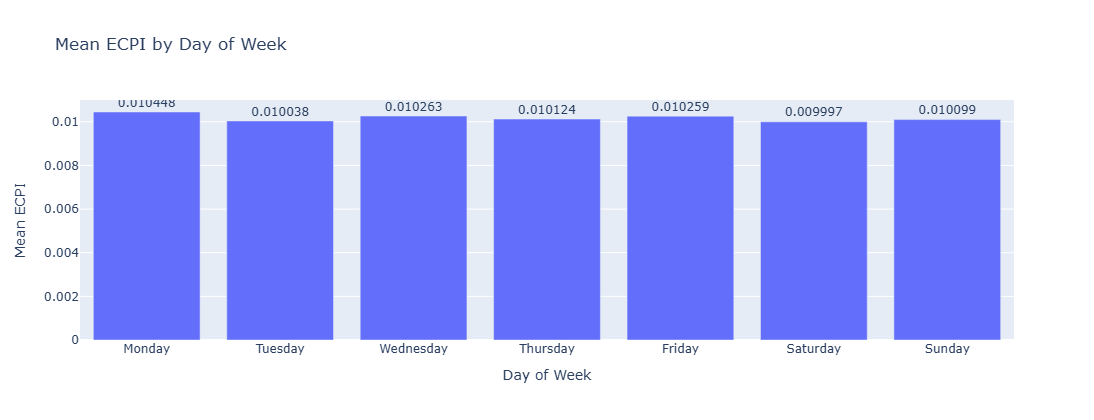

In [44]:
import plotly.express as px

ECPI = "expected_conv_per_impression"


weekday_map = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

dfp = df_clean.copy()

if "dayofweek" in dfp.columns:
    dfp["Weekday"] = dfp["dayofweek"].map(weekday_map)

weekday_ecpi = (
    dfp.groupby("Weekday")[ECPI]
       .agg(mean="mean", count="count")
       .reset_index()
)

weekday_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

weekday_ecpi["Weekday"] = pd.Categorical(
    weekday_ecpi["Weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_ecpi = weekday_ecpi.sort_values("Weekday")

fig = px.bar(
    weekday_ecpi,
    x="Weekday",
    y="mean",
    text="mean",
    title="Mean ECPI by Day of Week",
    hover_data={"mean":":.6f", "count":True}
)

fig.update_traces(
    texttemplate="%{text:.6f}",
    textposition="outside"
)

fig.update_layout(
    width=900,
    height=420,
    yaxis_title="Mean ECPI",
    xaxis_title="Day of Week"
)

fig.show()


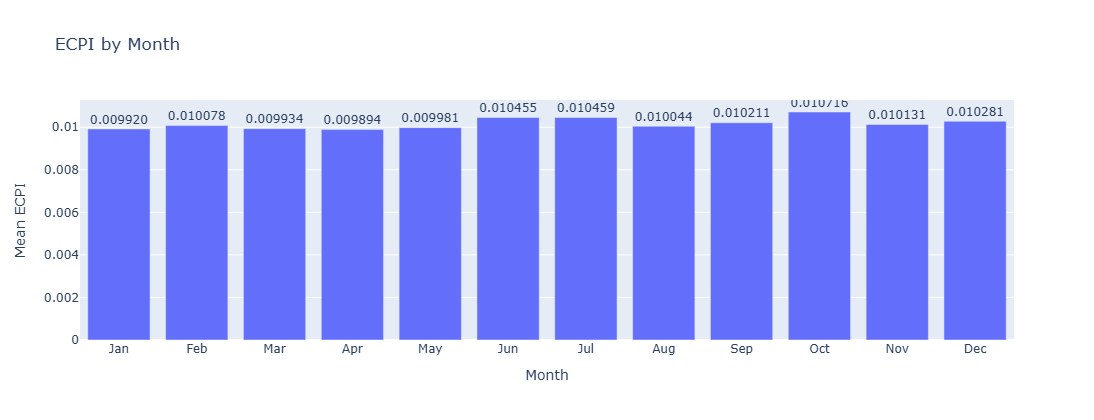

In [45]:
import plotly.express as px
import pandas as pd

ECPI = "expected_conv_per_impression"


MONTH_MAP = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}


tmp = df_clean.dropna(subset=[ECPI, "month"]).copy()
tmp["Month"] = pd.to_numeric(tmp["month"], errors="coerce")
tmp = tmp.dropna(subset=["Month"])
tmp["MonthName"] = tmp["Month"].astype(int).map(MONTH_MAP)


grp = (tmp.groupby("MonthName")[ECPI]
         .agg(mean="mean", count="count")
         .reset_index())


order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
grp["MonthName"] = pd.Categorical(grp["MonthName"], categories=order, ordered=True)
grp = grp.sort_values("MonthName")


fig = px.bar(
    grp,
    x="MonthName",
    y="mean",
    title="ECPI by Month",
    hover_data={"mean":":.6f", "count":True},
    text="mean"
)
fig.update_traces(texttemplate="%{text:.6f}", textposition="outside")
fig.update_layout(width=1000, height=420, xaxis_title="Month", yaxis_title="Mean ECPI")
fig.update_traces(
    hovertemplate="<b>%{x}</b><br>Mean ECPI: %{y:.6f}<br>Count: %{customdata[1]}<extra></extra>"
)
fig.show()


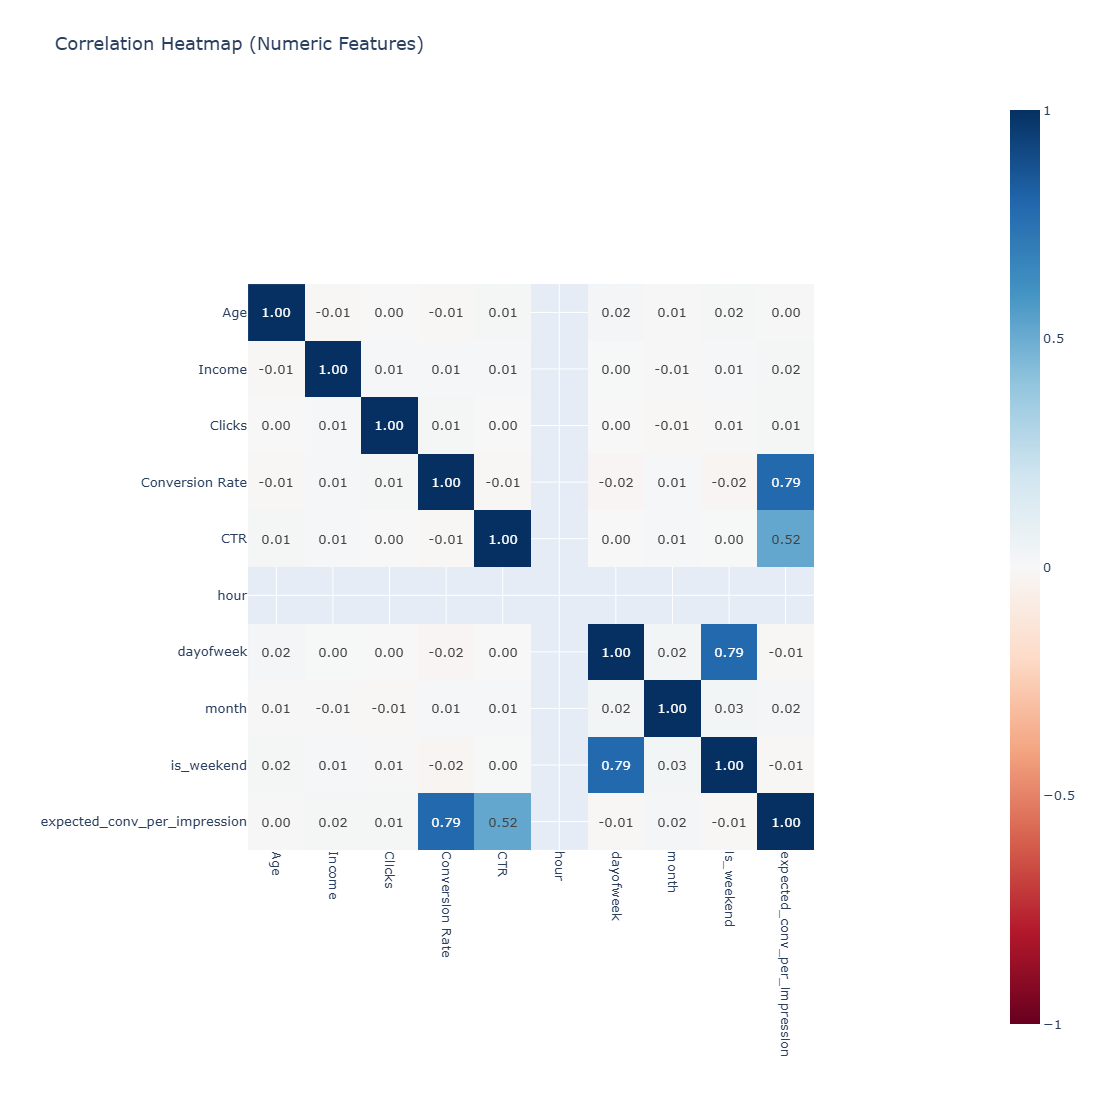

In [46]:
import plotly.express as px
import numpy as np

num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
corr = df_clean[num_cols].corr()

fig = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale="RdBu",
    zmin=-1, zmax=1,
    title="Correlation Heatmap (Numeric Features)"
)

fig.update_layout(
    width=1400,      # increased from 1000 → 1400
    height=1100,     # increased from 800  → 1100
    xaxis_title="",
    yaxis_title="",
    font=dict(size=13),
)

fig.update_xaxes(tickangle=90)

fig.update_traces(
    hovertemplate="<b>%{x}</b> vs <b>%{y}</b><br>Corr: %{z:.4f}<extra></extra>"
)

fig.show()


In [47]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from pandas.api.types import (
    is_object_dtype, is_bool_dtype, is_string_dtype,
    is_numeric_dtype, is_integer_dtype
)


def is_categorical_series(s: pd.Series, max_unique=30):
    if is_object_dtype(s) or is_string_dtype(s) or is_bool_dtype(s):
        return True
    if is_numeric_dtype(s):
        nunique = s.nunique(dropna=True)
        if is_integer_dtype(s) and nunique <= max_unique:
            return True
        return False
    return True

def coerce_numeric_if_mostly_numeric(s: pd.Series, threshold=0.8):
    if is_object_dtype(s) or is_string_dtype(s):
        s_num = pd.to_numeric(s, errors="coerce")
        if s_num.notna().mean() >= threshold:
            return s_num
    return s



WEEKDAY_MAP = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
MONTH_MAP   = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}

def apply_pretty_time_labels(feature_name: str, values) -> list:
    name = str(feature_name).lower()

    def to_int_safe(v):
        try:
            return int(float(v))
        except Exception:
            return None

    if name in {"dayofweek", "day_of_week", "weekday"}:
        return [WEEKDAY_MAP.get(to_int_safe(v), str(v)) for v in values]

    if name in {"month", "monthofyear", "month_of_year"}:
        return [MONTH_MAP.get(to_int_safe(v), str(v)) for v in values]

    return [str(v) for v in values]



def plot_feature_vs_target_interactive(
    df, feature, target, top_k=15, bins=10, min_count=30,
    width=1000, height=420
):
    tmp = df[[feature, target]].dropna().copy()
    if tmp.empty:
        return

    tmp[feature] = coerce_numeric_if_mostly_numeric(tmp[feature])

    title = f"{feature} → {target}"

    
    if is_categorical_series(tmp[feature]):
        counts = tmp[feature].value_counts(dropna=True)
        keep = counts.head(top_k).index
        tmp2 = tmp[tmp[feature].isin(keep)].copy()

        grp = (
            tmp2.groupby(feature)[target]
                .agg(mean="mean", count="count")
                .reset_index()
        )

        grp = grp[grp["count"] >= min_count].sort_values("mean", ascending=False)
        if grp.empty:
            return

        grp["label"] = apply_pretty_time_labels(feature, grp[feature].values)

        fig = px.bar(
            grp,
            x="label",
            y="mean",
            title=title,
            hover_data={"mean": ':.5f', "count": True},
        )
        fig.update_layout(
            width=width, height=height,
            xaxis_title=feature, yaxis_title=f"Mean {target}"
        )
        fig.update_xaxes(tickangle=-35)

        fig.update_traces(
            hovertemplate="<b>%{x}</b><br>Mean: %{y:.5f}<br>Count: %{customdata[0]}<extra></extra>"
        )
        fig.show()
        return

    
    x_num = pd.to_numeric(tmp[feature], errors="coerce")
    tmp2 = tmp.assign(**{feature: x_num}).dropna()
    if tmp2.empty:
        return

    try:
        tmp2["bin"] = pd.cut(tmp2[feature], bins=bins)
    except Exception:
        return

    grp = (
        tmp2.groupby("bin", observed=True)[target]
            .agg(mean="mean", count="count")
            .reset_index()
    )
    grp = grp[grp["count"] >= min_count].copy()
    if grp.empty:
        return

    grp["bin_mid"] = grp["bin"].apply(lambda iv: iv.mid)
    grp = grp.sort_values("bin_mid")

    fig = px.line(
        grp,
        x="bin_mid",
        y="mean",
        markers=True,
        title=title,
        hover_data={"mean": ':.5f', "count": True},
    )
    fig.update_layout(
        width=width, height=height,
        xaxis_title=feature, yaxis_title=f"Mean {target}"
    )
    fig.update_traces(
        hovertemplate="<b>%{x:.2f}</b><br>Mean: %{y:.5f}<br>Count: %{customdata[0]}<extra></extra>"
    )
    fig.show()


def plot_all_features_against_targets_interactive(df, targets, exclude=None, top_k=15, bins=10, min_count=30):
    exclude = set(exclude or [])
    cols = [c for c in df.columns if c not in exclude]

    for t in targets:
        print(f"\n==================== Feature effects for target: {t} ====================")
        for c in cols:
            if c == t:
                continue
            if df[c].nunique(dropna=True) <= 1:
                continue
            plot_feature_vs_target_interactive(df, c, t, top_k=top_k, bins=bins, min_count=min_count)



def placement_map_interactive(df, placement_col, ctr_col, conv_col, target_for_color="expected_conv_per_impression"):
    d = df.dropna(subset=[placement_col, ctr_col, conv_col]).copy()
    agg = d.groupby(placement_col).agg(
        mean_ctr=(ctr_col, "mean"),
        mean_conv=(conv_col, "mean"),
        n=(placement_col, "size"),
        mean_target=(target_for_color, "mean") if target_for_color in d.columns else (ctr_col, "mean")
    ).reset_index()

    agg = agg.rename(columns={placement_col: "Placement"})

  
    fig2d = px.scatter(
        agg,
        x="mean_ctr",
        y="mean_conv",
        size="n",
        color="mean_target",
        hover_data={"Placement": True, "mean_ctr":":.4f", "mean_conv":":.4f", "mean_target":":.5f", "n": True},
        title="Placement Map"
    )
    fig2d.update_layout(xaxis_title="Mean CTR", yaxis_title="Mean ConvRate")
    fig2d.show()

  
    fig3d = px.scatter_3d(
        agg,
        x="mean_ctr",
        y="mean_conv",
        z="n",
        size="n",
        color="mean_target",
        hover_data={"Placement": True, "mean_ctr":":.4f", "mean_conv":":.4f", "mean_target":":.5f", "n": True},
        title="3D Placement"
    )
    fig3d.update_layout(scene=dict(
        xaxis_title="Mean CTR",
        yaxis_title="Mean ConvRate",
        zaxis_title="Freq"
    ))
    fig3d.show()



==================== Feature effects for target: CTR ====================


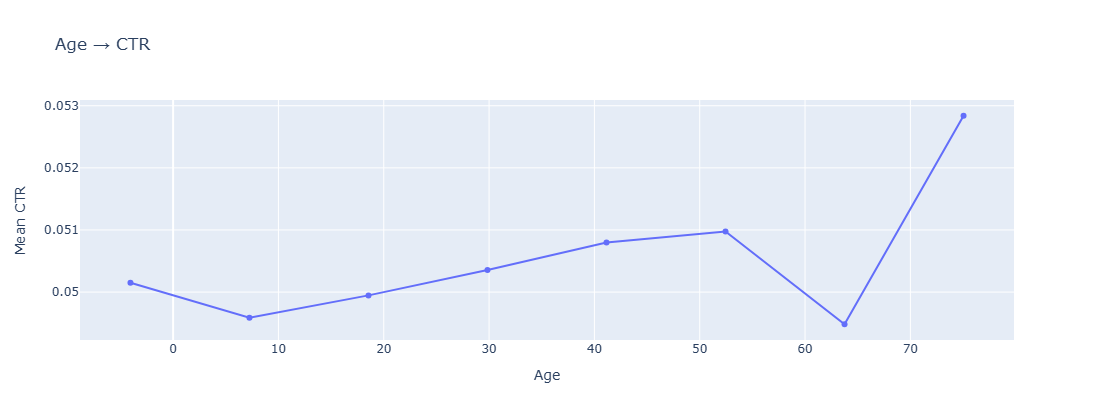

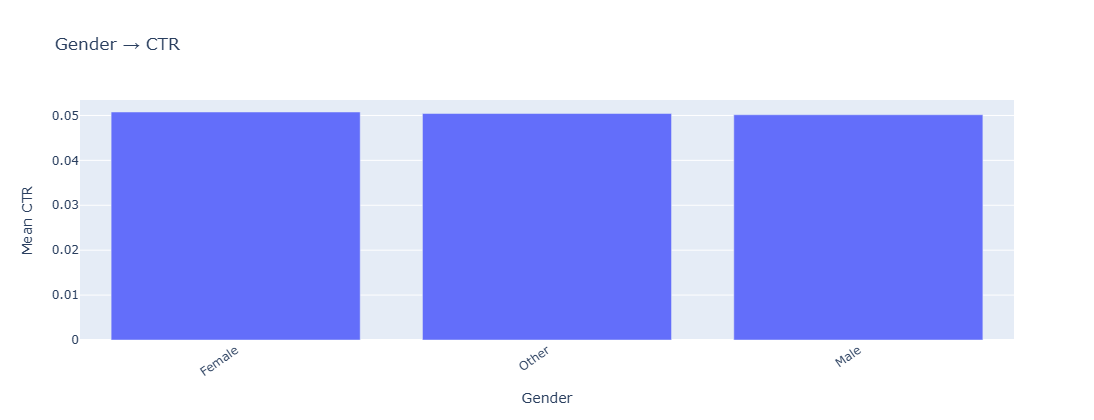

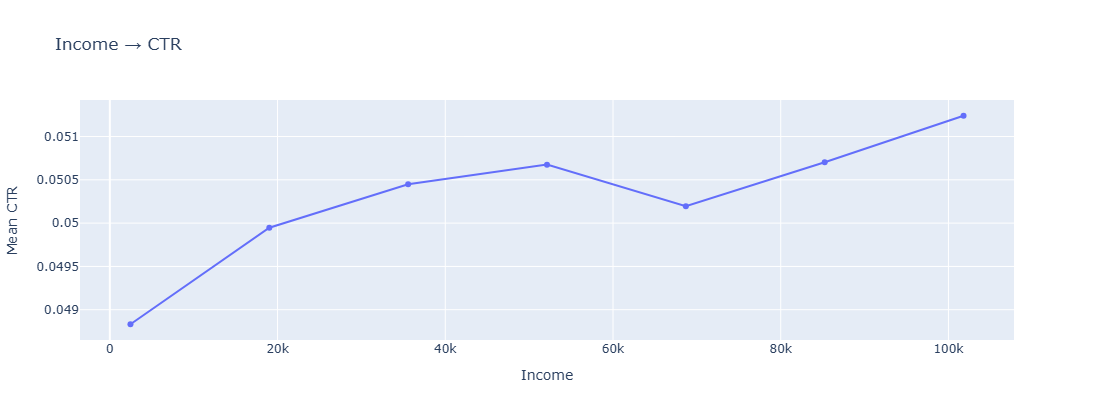

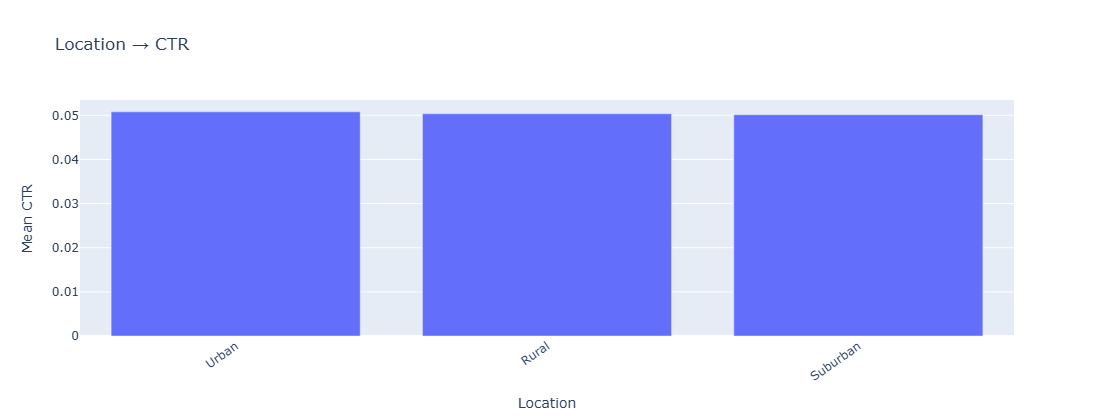

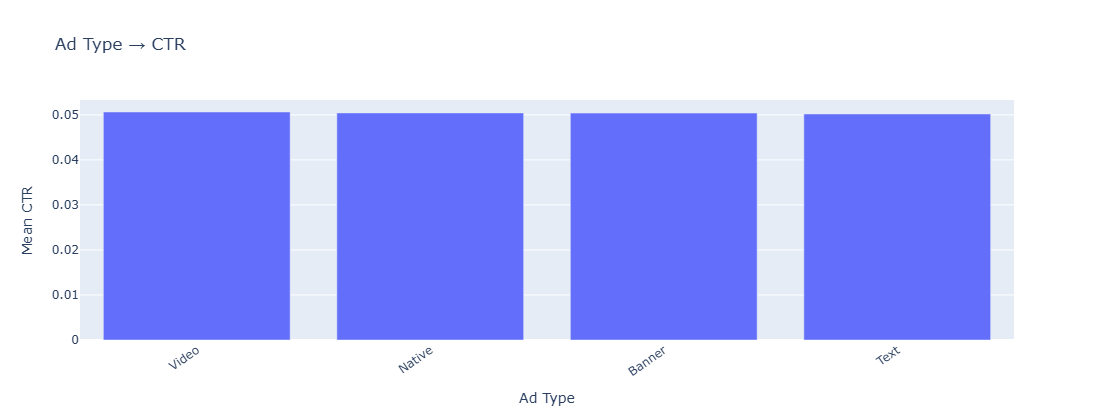

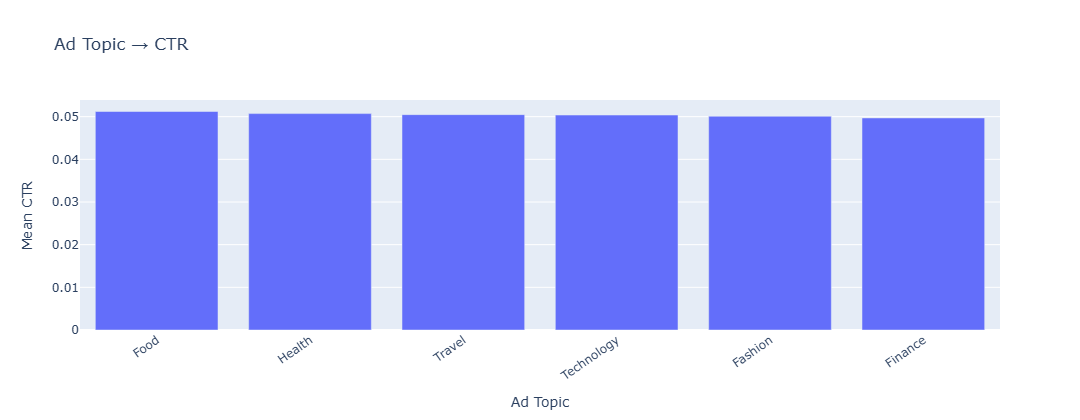

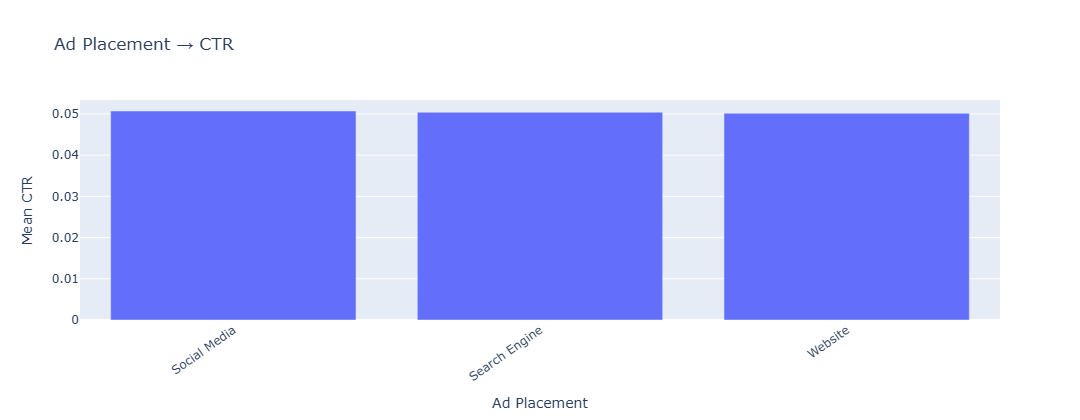

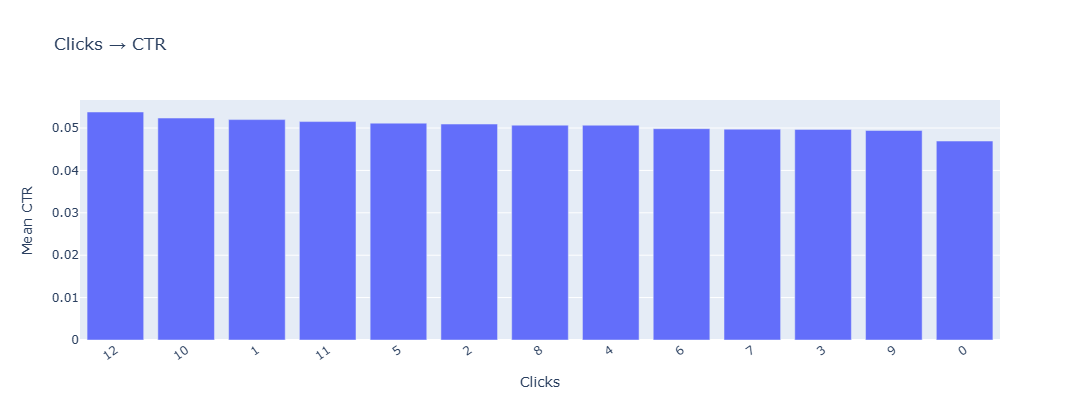

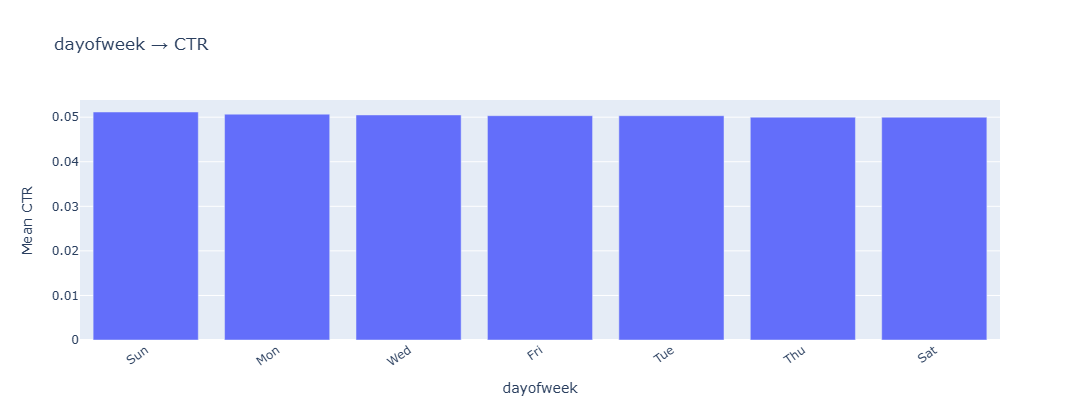

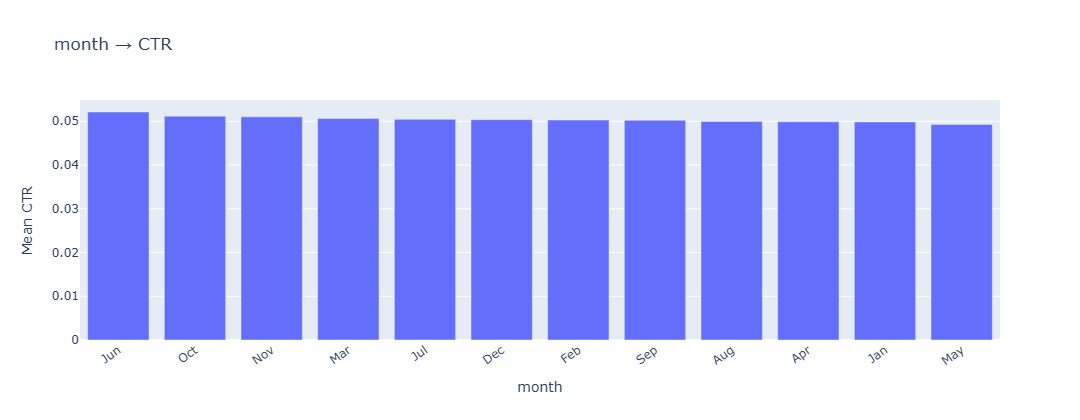

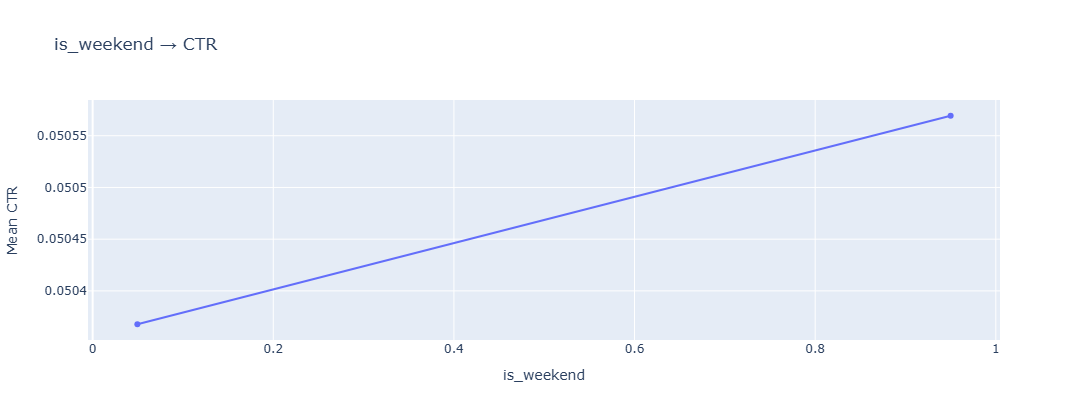


==================== Feature effects for target: Conversion Rate ====================


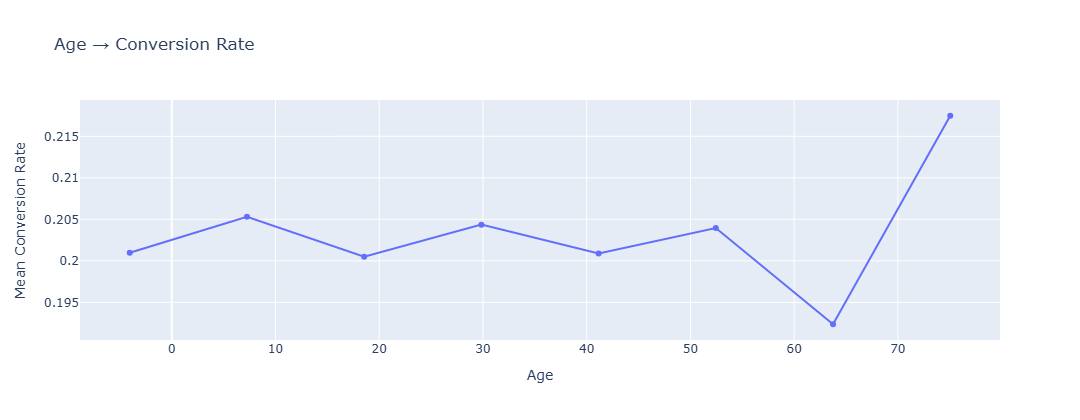

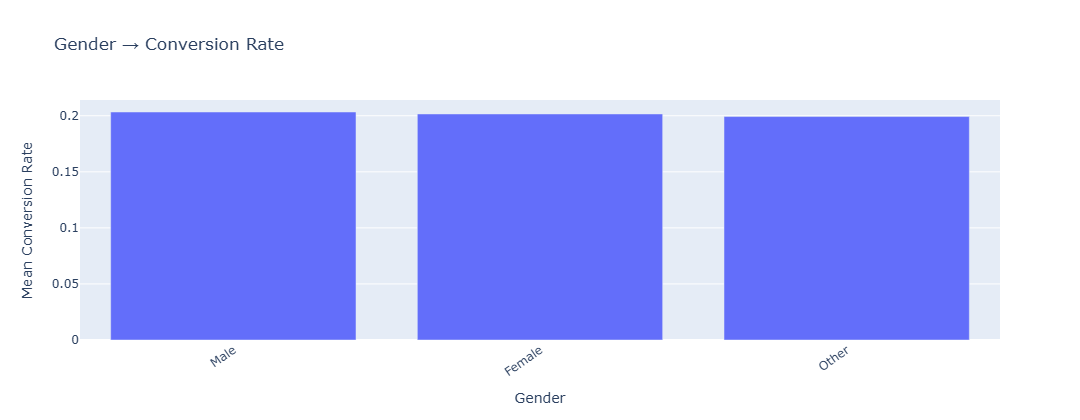

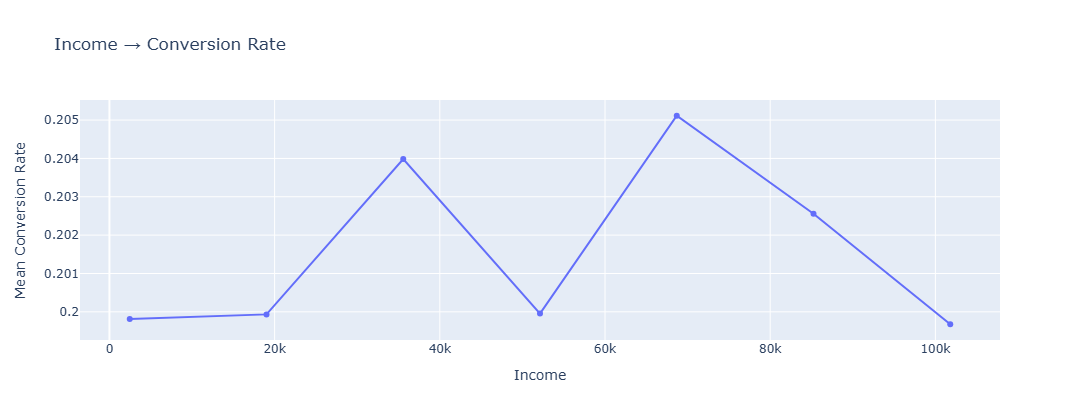

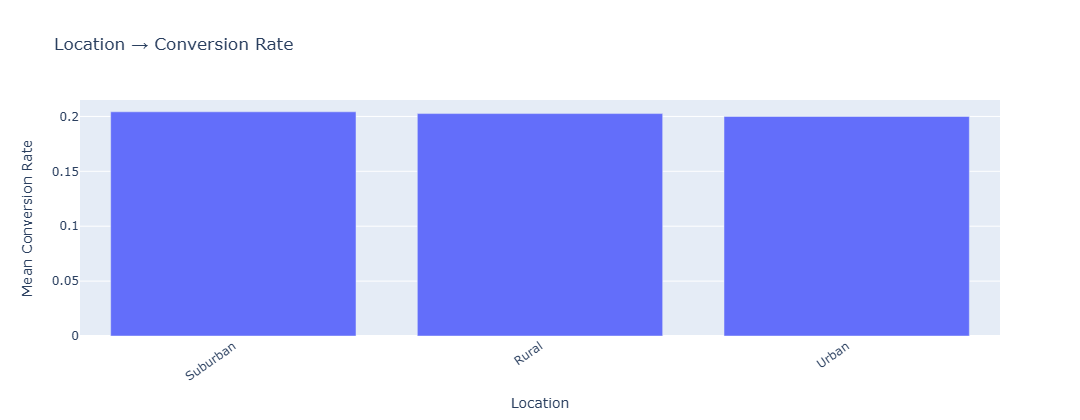

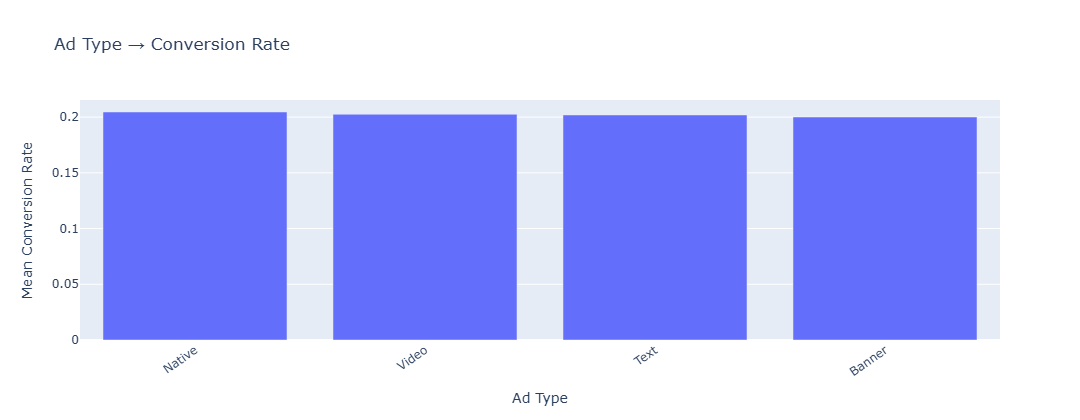

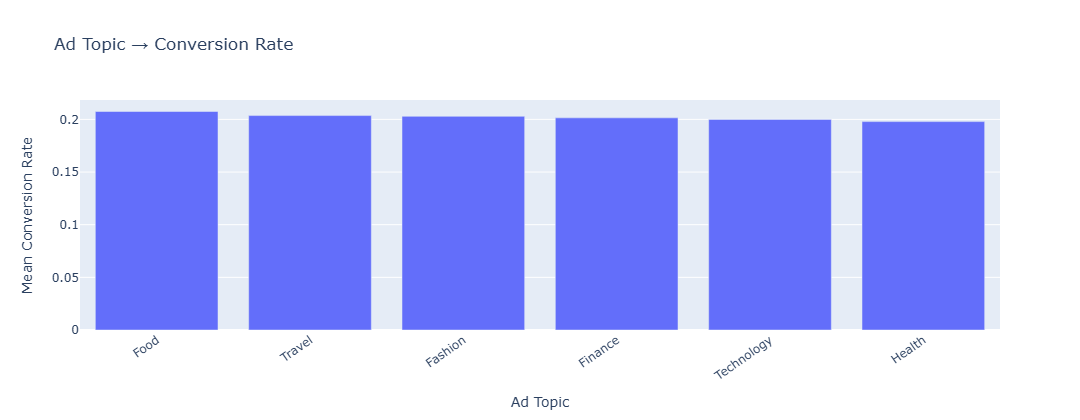

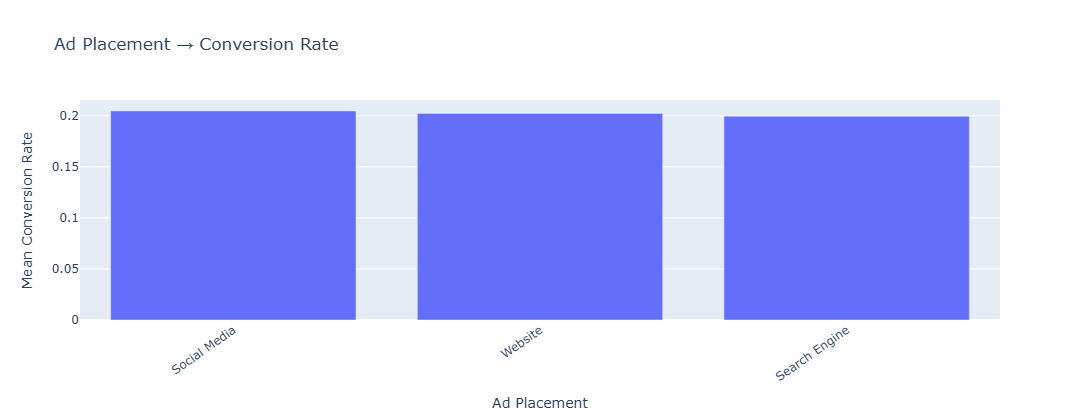

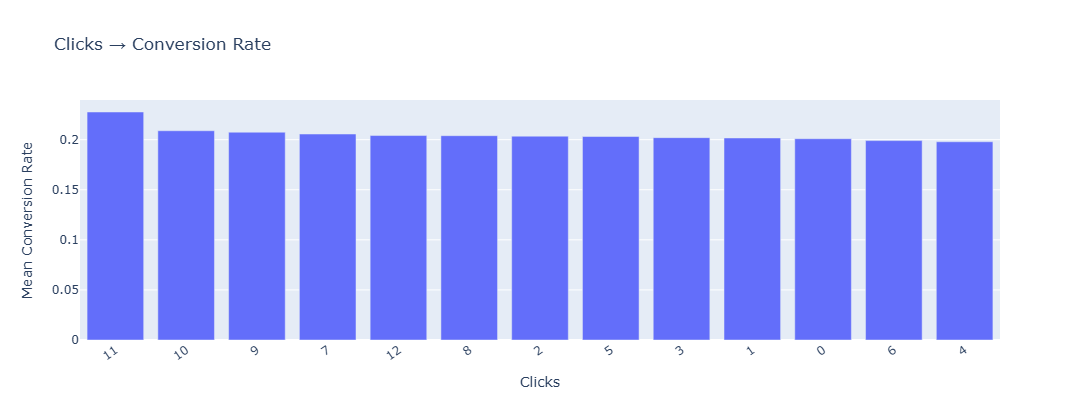

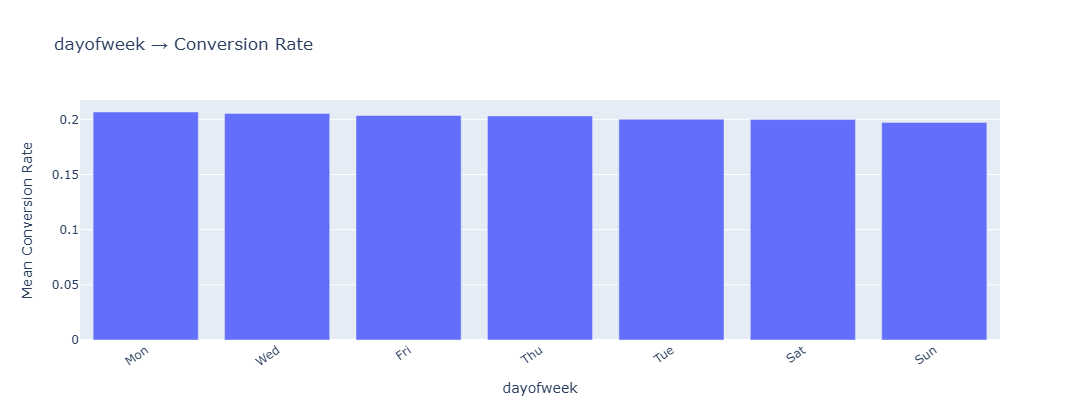

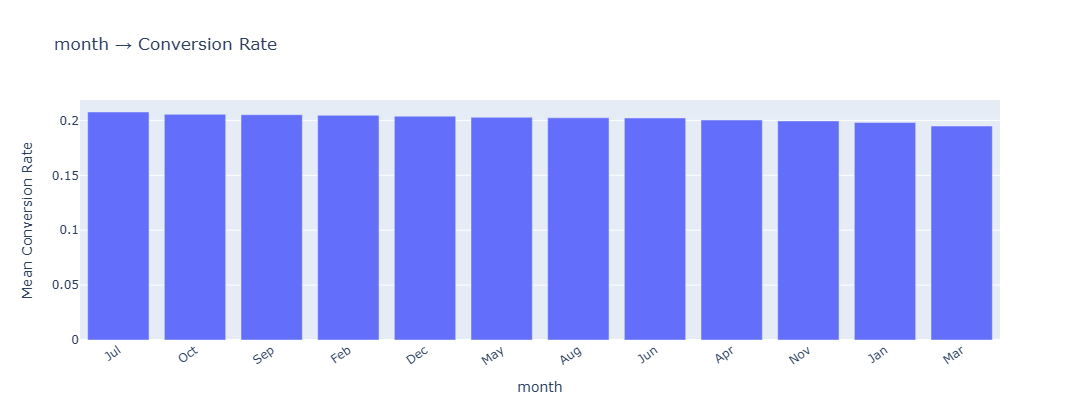

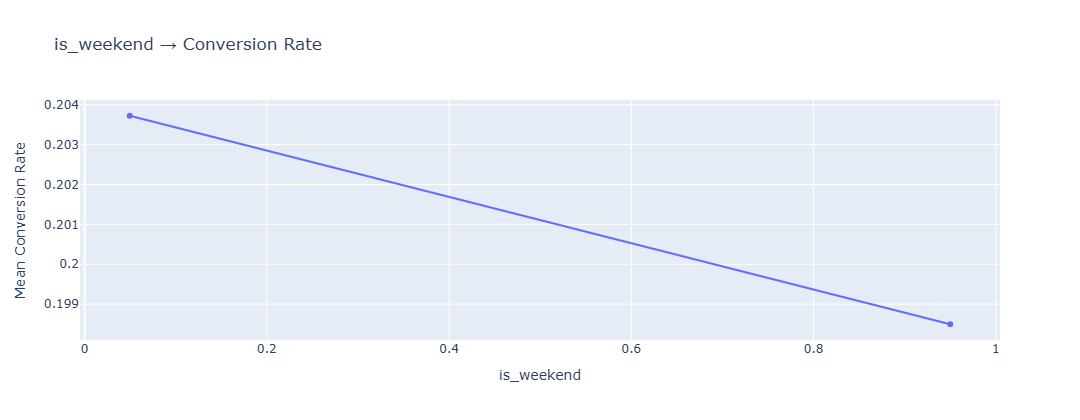


==================== Feature effects for target: expected_conv_per_impression ====================


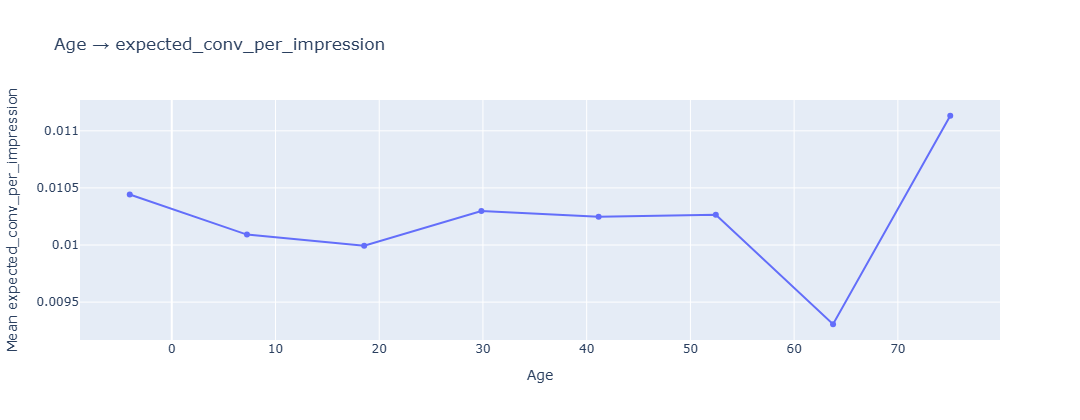

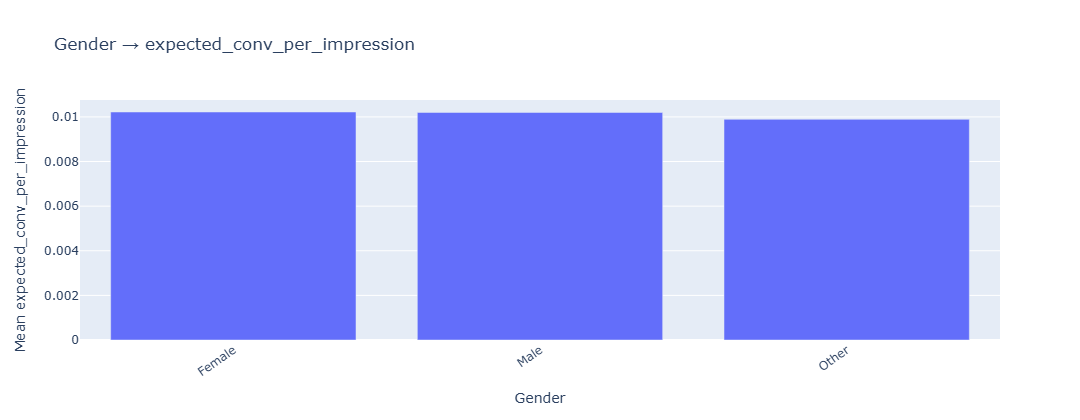

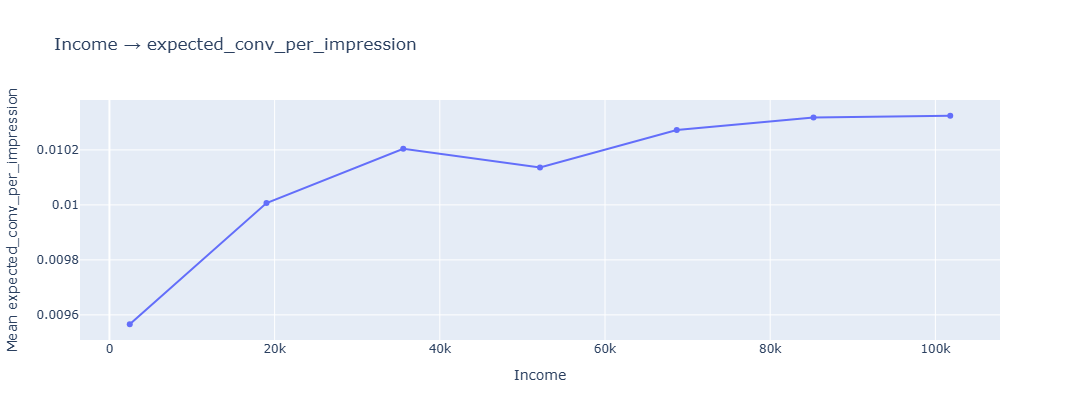

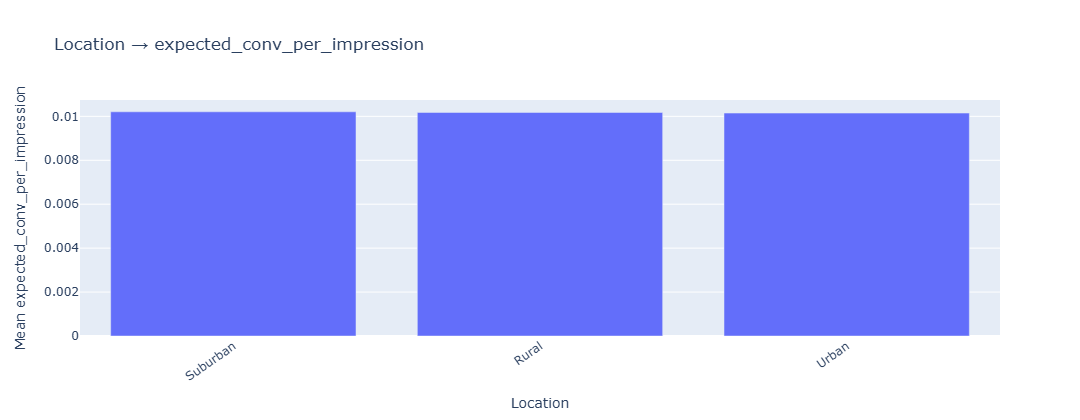

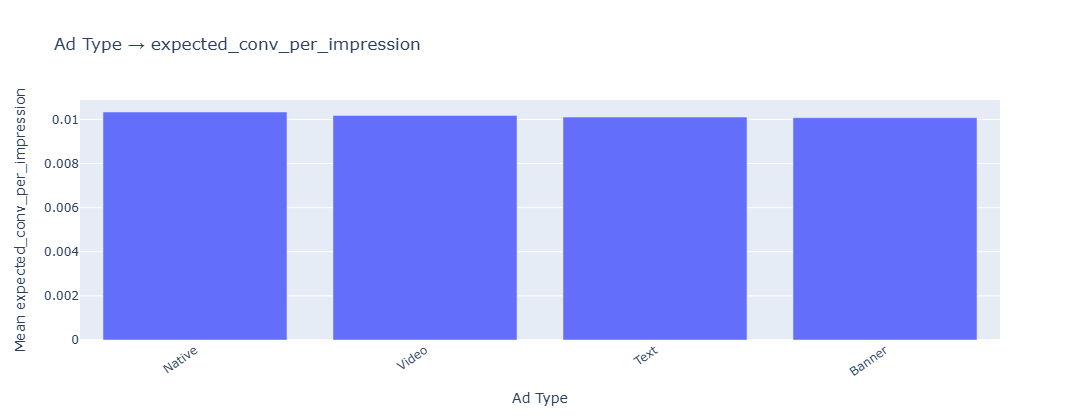

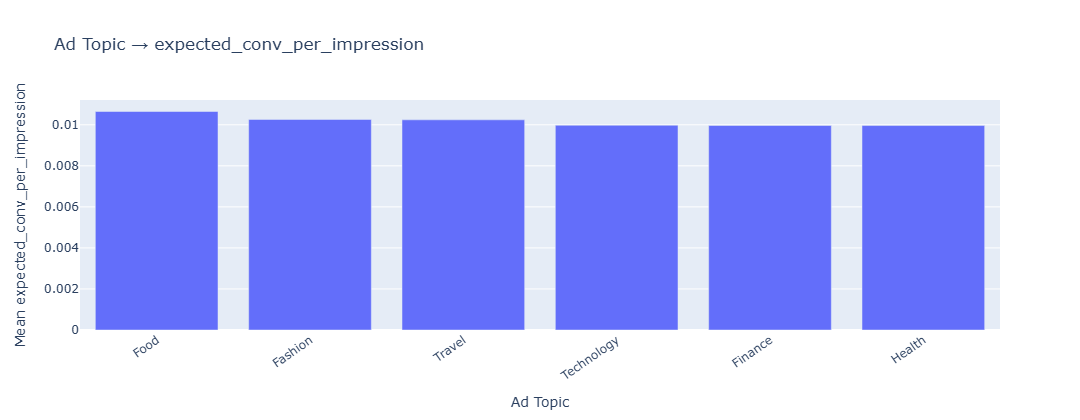

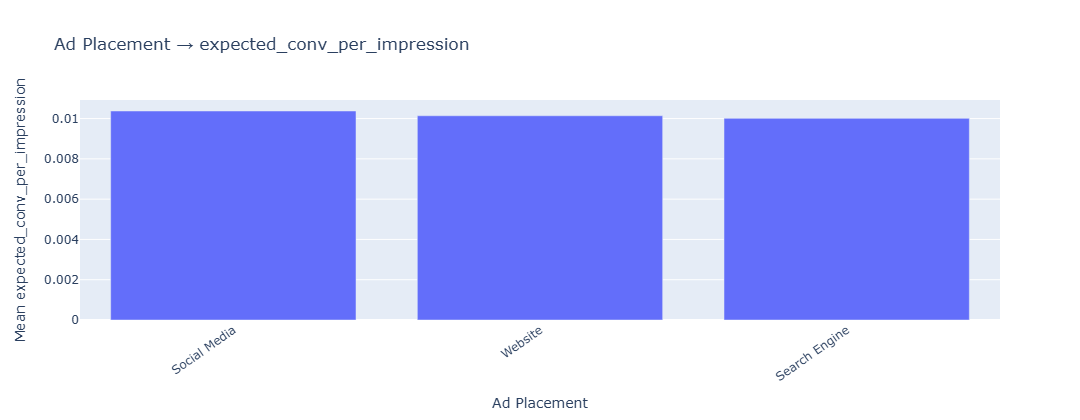

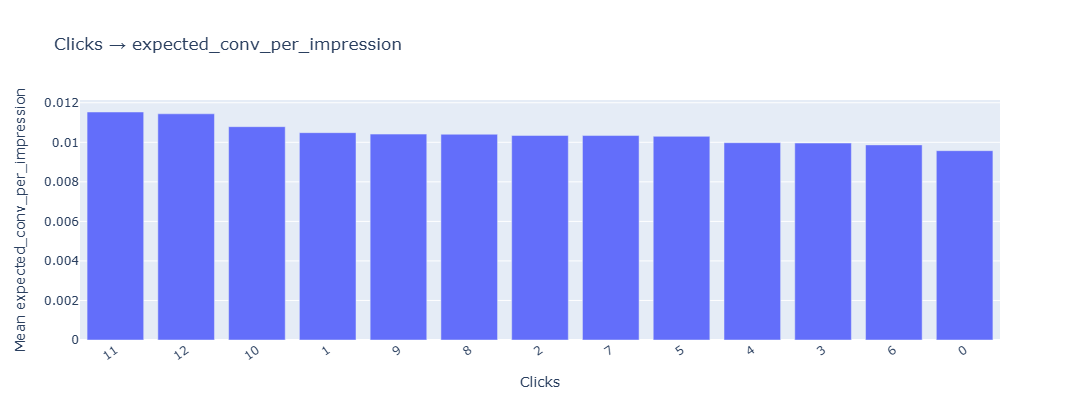

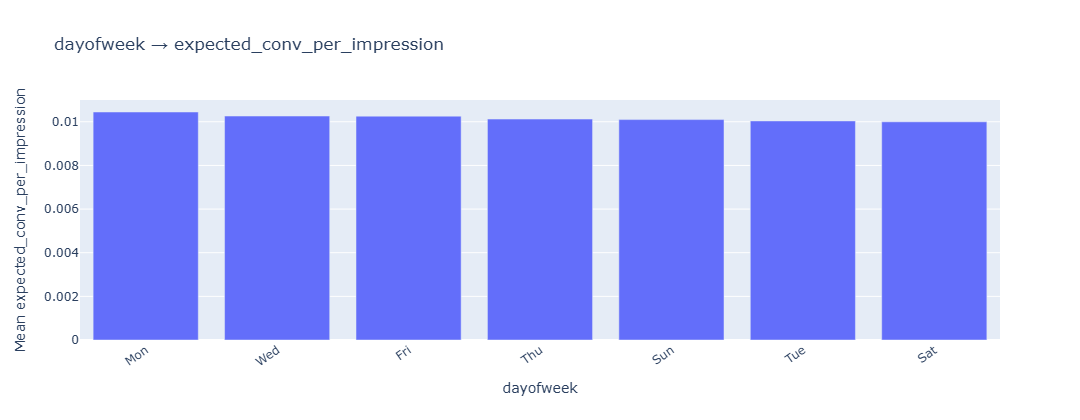

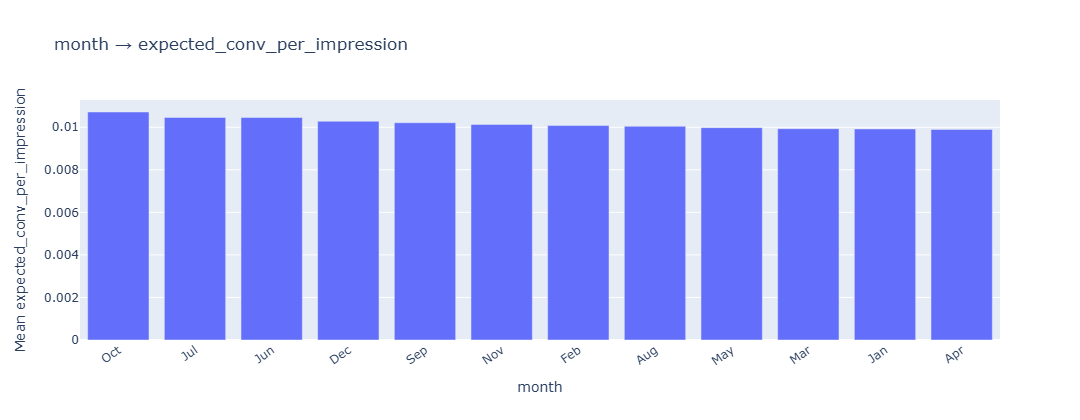

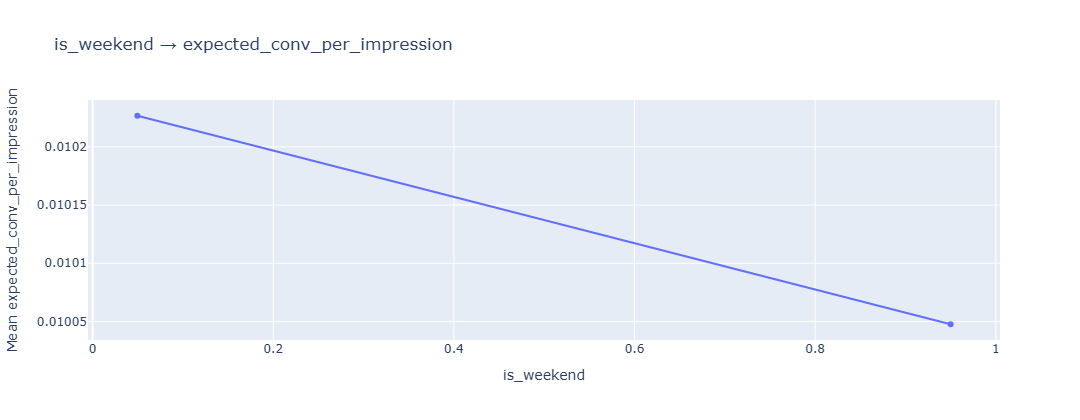

In [48]:
targets = [col_ctr, col_conv, "expected_conv_per_impression"]
exclude_cols = set([col_ctr, col_conv, "expected_conv_per_impression"])

plot_all_features_against_targets_interactive(
    df_clean,
    targets=targets,
    exclude=exclude_cols,
    top_k=15,
    bins=10,
    min_count=30
)


Training and evaluating all models on the same 80/20 split …

  Ridge Regression
    MAE  = 0.000001
    RMSE = 0.000001
    R²   = 1.000000

  Random Forest
    MAE  = 0.000007
    RMSE = 0.000057
    R²   = 0.999944

  HistGradientBoosting
    MAE  = 0.000065
    RMSE = 0.000323
    R²   = 0.998188

MODEL COMPARISON TABLE


,MAE,RMSE,R²
Ridge Regression,0.000001,0.000001,1.000000
Random Forest,0.000007,0.000057,0.999944
HistGradientBoosting,0.000065,0.000323,0.998188


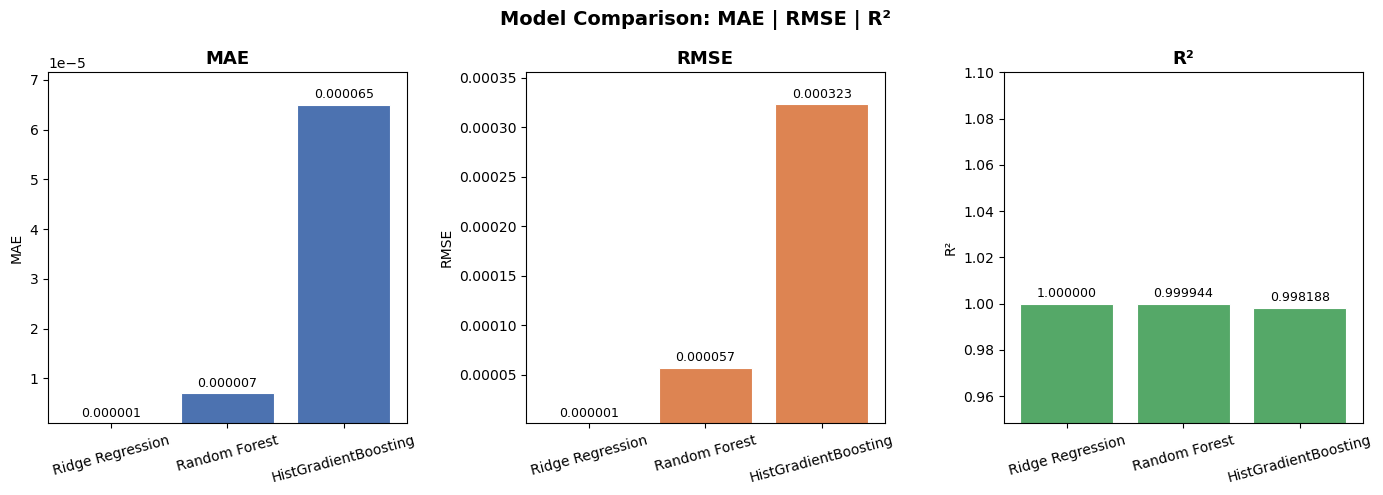

WHY HistGradientBoosting IS THE BEST MODEL
`pipe` is set to the winning HistGradientBoosting pipeline.


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas.api.types import is_object_dtype, is_string_dtype, is_bool_dtype
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



RANDOM_STATE = 42
TEST_SIZE    = 0.2

TARGET        = "expected_conv_per_impression"
PLACEMENT_COL = col_placement




def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    cat_cols = [c for c in X.columns if is_object_dtype(X[c]) or is_string_dtype(X[c]) or is_bool_dtype(X[c])]
    num_cols = [c for c in X.columns if c not in cat_cols]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),           # helps Ridge especially
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe",     OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols),
        ],
        remainder="drop"
    )


data = df_clean.dropna(subset=[TARGET, PLACEMENT_COL]).copy()
y    = pd.to_numeric(data[TARGET], errors="coerce")
data = data.loc[y.notna()].copy()
y    = y.loc[y.notna()].copy()


leakage = [
    c for c in data.columns
    if str(c).lower() in {"ctr", "conversion rate", "conversion_rate",
                          "expected_conv_per_impression"}
    and c != TARGET
]
X = data.drop(columns=leakage, errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

pre = build_preprocessor(X_train)



models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest":    RandomForestRegressor(
                            n_estimators=200,
                            max_depth=10,
                            random_state=RANDOM_STATE,
                            n_jobs=-1,
                        ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
                            learning_rate=0.05,
                            max_depth=8,
                            max_iter=800,
                            random_state=RANDOM_STATE,
                        ),
}


results = {}
pipes   = {}

print("Training and evaluating all models on the same 80/20 split …\n")

for name, mdl in models.items():
    p = Pipeline([("pre", pre), ("model", mdl)])
    p.fit(X_train, y_train)
    pred = p.predict(X_test)

    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R²": r2}
    pipes[name]   = p

    print(f"  {name}")
    print(f"    MAE  = {mae:.6f}")
    print(f"    RMSE = {rmse:.6f}")
    print(f"    R²   = {r2:.6f}")
    print()



compare_df = pd.DataFrame(results).T.round(6)
print("=" * 55)
print("MODEL COMPARISON TABLE")
print("=" * 55)
display(compare_df)



fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metric_names = ["MAE", "RMSE", "R²"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, metric, color in zip(axes, metric_names, colors):
    vals = compare_df[metric]
    bars = ax.bar(vals.index, vals.values, color=color, edgecolor="white", linewidth=0.8)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=15)
    
    # Fix empty space: set y-axis to start just below the minimum value
    ymin = vals.min() * 0.95
    ymax = vals.max() * 1.1
    ax.set_ylim(ymin, ymax)
    
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (ymax - ymin) * 0.01,
                f"{v:.6f}",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("Model Comparison: MAE | RMSE | R²", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


best_name = compare_df["R²"].idxmax()

print("WHY HistGradientBoosting IS THE BEST MODEL")



pipe = pipes["HistGradientBoosting"]
print("`pipe` is set to the winning HistGradientBoosting pipeline.")


In [52]:
import plotly.express as px

def get_test_split_for_plot(df, target, placement_col, test_size=0.2, random_state=42):
    """
    Rebuild the SAME X/y split logic used inside the training cell
    so we can plot actual vs predicted on the held-out test set.
    """
    data = df.dropna(subset=[target, placement_col]).copy()

    y = pd.to_numeric(data[target], errors="coerce")
    data = data.loc[y.notna()].copy()
    y = y.loc[y.notna()].copy()

    
    leakage = []
    for c in data.columns:
        cl = str(c).lower()
        if cl in {"ctr", "conversion rate", "conversion_rate", "expected_conv_per_impression"} and c != target:
            leakage.append(c)

    X = data.drop(columns=leakage, errors="ignore")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    return X_test, y_test



X_test, y_test = get_test_split_for_plot(
    df_clean, TARGET, PLACEMENT_COL, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

y_pred = pipe.predict(X_test)

df_plot = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

fig = px.scatter(
    df_plot,
    x="Actual",
    y="Predicted",
    title="Actual vs Predicted — HistGradientBoosting (Test Set)",
    hover_data={"Actual":":.6f", "Predicted":":.6f"},
)

mn = float(min(df_plot["Actual"].min(), df_plot["Predicted"].min()))
mx = float(max(df_plot["Actual"].max(), df_plot["Predicted"].max()))
fig.add_shape(type="line", x0=mn, y0=mn, x1=mx, y1=mx, line=dict(dash="dash"))
fig.update_layout(width=800, height=600)
fig.show()


In [34]:
# ── Streamlit dashboard (inline notebook version) ───────────────────
# Run this cell to confirm the dashboard code is correct,
# then launch it with:  streamlit run ads_dashboard.py

import numpy as np
import pandas as pd
import streamlit as st
import plotly.express as px

st.set_page_config(page_title="Ad Performance Dashboard", page_icon="📊", layout="wide")

# =============================
# Helpers: column detection
# =============================
def find_col_contains(candidates, columns):
    cols_lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    for cand in candidates:
        for c in columns:
            if cand.lower() in c.lower():
                return c
    return None

def normalize_rate(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
    mx = np.nanmax(s.values) if np.any(~np.isnan(s.values)) else np.nan
    if not np.isnan(mx) and mx > 1.5:  # looks like percent
        s = s / 100.0
    return s.clip(0, 1)

MONTH_MAP = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
MONTH_ORDER = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
WEEKDAY_MAP = {0:"Monday",1:"Tuesday",2:"Wednesday",3:"Thursday",4:"Friday",5:"Saturday",6:"Sunday"}
WEEKDAY_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

ECPI = "expected_conv_per_impression"

@st.cache_data
def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    for c in df.select_dtypes(include=["object"]).columns:
        df[c] = df[c].astype(str).str.strip()
    return df

def ensure_time_features(df: pd.DataFrame, ts_col) -> pd.DataFrame:
    out = df.copy()
    if ts_col and ts_col in out.columns:
        ts = pd.to_datetime(out[ts_col], errors="coerce")
        if "hour" not in out.columns:
            out["hour"] = ts.dt.hour
        if "dayofweek" not in out.columns:
            out["dayofweek"] = ts.dt.dayofweek
        if "month" not in out.columns:
            out["month"] = ts.dt.month
        if "is_weekend" not in out.columns:
            out["is_weekend"] = (ts.dt.dayofweek >= 5).astype(int)
    return out

def add_bins(df: pd.DataFrame, col_age=None, col_income=None) -> pd.DataFrame:
    out = df.copy()

    if col_age and col_age in out.columns:
        age = pd.to_numeric(out[col_age], errors="coerce")
        out["AgeGroup"] = pd.cut(age, bins=[0, 29, 49, 200], labels=["Young", "Middle", "Elder"])

    if col_income and col_income in out.columns:
        inc = pd.to_numeric(out[col_income], errors="coerce")
        try:
            out["IncomeGroup"] = pd.qcut(inc, q=3, labels=["Low", "Medium", "High"])
        except Exception:
            out["IncomeGroup"] = pd.cut(inc, bins=3, labels=["Low", "Medium", "High"])

    if "dayofweek" in out.columns:
        out["Weekday"] = pd.to_numeric(out["dayofweek"], errors="coerce").map(WEEKDAY_MAP)

    if "month" in out.columns:
        m = pd.to_numeric(out["month"], errors="coerce")
        out["MonthName"] = m.dropna().astype(int).map(MONTH_MAP)

    return out


def plot_mean_ecpi_by_category(df, cat_col, title, top_k=20, min_count=30, height=420):
    if cat_col is None or cat_col not in df.columns:
        st.info(f"Column not found: {cat_col}")
        return
    tmp = df[[cat_col, ECPI]].dropna().copy()
    if tmp.empty:
        st.info(f"No data for {title}")
        return
    keep = tmp[cat_col].value_counts().head(top_k).index
    tmp = tmp[tmp[cat_col].isin(keep)]
    grp = tmp.groupby(cat_col)[ECPI].agg(mean="mean", count="count").reset_index()
    grp = grp[grp["count"] >= min_count].sort_values("mean", ascending=False)
    if grp.empty:
        st.info(f"Skip: {title} (no categories with count >= {min_count})")
        return
    fig = px.bar(grp, x=cat_col, y="mean", text="mean", title=title, hover_data={"mean":":.6f", "count":True})
    fig.update_traces(texttemplate="%{text:.6f}", textposition="outside")
    fig.update_layout(height=height, xaxis_tickangle=-35, yaxis_title="Mean ECPI")
    fig.update_traces(hovertemplate="<b>%{x}</b><br>Mean ECPI: %{y:.6f}<br>Count: %{customdata[1]}<extra></extra>")
    st.plotly_chart(fig, use_container_width=True)

st.title("📊 Advertising Performance Dashboard")
st.caption("Interactive ECPI analytics with filters (Streamlit + Plotly)")

DATA_PATH = st.sidebar.text_input("Dataset path", value="Dataset_Ads.csv")
df_raw = load_data(DATA_PATH)

col_ctr = find_col_contains(["CTR","click_through_rate","clickthroughrate"], df_raw.columns)
col_conv = find_col_contains(["Conversion Rate","conversion_rate","ConversionRate"], df_raw.columns)
col_ts = find_col_contains(["Timestamp","time","datetime","date"], df_raw.columns)

col_placement = find_col_contains(["Ad Placement","placement","ad_placement"], df_raw.columns)
col_topic     = find_col_contains(["Ad Topic","Topic","AdTopic"], df_raw.columns)
col_type      = find_col_contains(["Ad Type","Type","AdType"], df_raw.columns)
col_location  = find_col_contains(["Location","country","region","city"], df_raw.columns)
col_gender    = find_col_contains(["Gender","sex"], df_raw.columns)
col_age       = find_col_contains(["Age"], df_raw.columns)
col_income    = find_col_contains(["Income"], df_raw.columns)

df = ensure_time_features(df_raw, col_ts)

if ECPI not in df.columns:
    if col_ctr is None or col_conv is None:
        st.error(f"ECPI '{ECPI}' not found and CTR/Conv not detected.")
        st.stop()
    df[col_ctr] = normalize_rate(df[col_ctr])
    df[col_conv] = normalize_rate(df[col_conv])
    df[ECPI] = (df[col_ctr] * df[col_conv]).clip(0, 1)

df = add_bins(df, col_age=col_age, col_income=col_income)

st.sidebar.header("🔎 Filters")

def multiselect_filter(label, df, col):
    if col and col in df.columns:
        opts = sorted(df[col].dropna().astype(str).unique().tolist())
        return st.sidebar.multiselect(label, opts, default=opts)
    return None

sel_placement = multiselect_filter("Ad Placement", df, col_placement)
sel_topic     = multiselect_filter("Ad Topic", df, col_topic)
sel_type      = multiselect_filter("Ad Type", df, col_type)
sel_location  = multiselect_filter("Location", df, col_location)
sel_gender    = multiselect_filter("Gender", df, col_gender)

sel_weekday = st.sidebar.multiselect("Weekday", WEEKDAY_ORDER, default=WEEKDAY_ORDER) if "Weekday" in df.columns else None
sel_month   = st.sidebar.multiselect("Month", MONTH_ORDER, default=MONTH_ORDER) if "MonthName" in df.columns else None

min_count = st.sidebar.slider("Min category count (bar charts)", 5, 100, 30, 5)
top_k     = st.sidebar.slider("Top categories shown", 5, 40, 20, 1)

df_f = df.copy()

def apply_in_filter(df_in, col, selected):
    if col and selected is not None:
        return df_in[df_in[col].astype(str).isin(set(map(str, selected)))]
    return df_in

df_f = apply_in_filter(df_f, col_placement, sel_placement)
df_f = apply_in_filter(df_f, col_topic, sel_topic)
df_f = apply_in_filter(df_f, col_type, sel_type)
df_f = apply_in_filter(df_f, col_location, sel_location)
df_f = apply_in_filter(df_f, col_gender, sel_gender)

if sel_weekday is not None and "Weekday" in df_f.columns:
    df_f = df_f[df_f["Weekday"].astype(str).isin(sel_weekday)]
if sel_month is not None and "MonthName" in df_f.columns:
    df_f = df_f[df_f["MonthName"].astype(str).isin(sel_month)]

df_f = df_f.dropna(subset=[ECPI])

c1, c2, c3, c4 = st.columns(4)
c1.metric("Rows", f"{len(df_f):,}")
c2.metric("Mean ECPI", f"{df_f[ECPI].mean():.6f}" if len(df_f) else "—")
c3.metric("Median ECPI", f"{df_f[ECPI].median():.6f}" if len(df_f) else "—")
c4.metric("Unique Placements", f"{df_f[col_placement].nunique():,}" if col_placement else "—")

st.divider()

# ── ECPI distribution + heatmap side by side ─────────────────────────
left, right = st.columns([1.0, 1.0])
with left:
    fig = px.histogram(df_f, x=ECPI, nbins=40, title="ECPI Distribution", hover_data={ECPI:":.6f"})
    fig.update_layout(height=480, xaxis_title="ECPI", yaxis_title="Count")
    st.plotly_chart(fig, use_container_width=True)

with right:
    num_cols = df_f.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols) >= 2:
        corr = df_f[num_cols].corr()
        # PROFESSOR FIX 2: Bigger heatmap height on the dashboard
        fig = px.imshow(
            corr,
            text_auto=".2f",
            color_continuous_scale="RdBu",
            zmin=-1, zmax=1,
            title="Correlation Heatmap"
        )
        fig.update_layout(
            height=700,          # was 380 — now much taller
            font=dict(size=11),
        )
        fig.update_xaxes(tickangle=90)
        fig.update_traces(hovertemplate="<b>%{x}</b> vs <b>%{y}</b><br>Corr: %{z:.4f}<extra></extra>")
        st.plotly_chart(fig, use_container_width=True)

st.divider()

a, b = st.columns(2)
with a:
    plot_mean_ecpi_by_category(df_f, col_placement, "Mean ECPI by Placement", top_k=top_k, min_count=min_count)
with b:
    plot_mean_ecpi_by_category(df_f, col_topic, "Mean ECPI by Topic", top_k=top_k, min_count=min_count)

with st.expander("📄 Preview filtered rows"):
    st.dataframe(df_f.head(200), use_container_width=True)


TypeError: Descriptors cannot be created directly.
If this call came from a _pb2.py file, your generated code is out of date and must be regenerated with protoc >= 3.19.0.
If you cannot immediately regenerate your protos, some other possible workarounds are:
 1. Downgrade the protobuf package to 3.20.x or lower.
 2. Set PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION=python (but this will use pure-Python parsing and will be much slower).

More information: https://developers.google.com/protocol-buffers/docs/news/2022-05-06#python-updates

In [28]:
import os

DASHBOARD_PATH = "ads_dashboard.py"

dashboard_code = r'''
# ====== STREAMLIT DASHBOARD APP ======
import numpy as np
import pandas as pd
import streamlit as st
import plotly.express as px

st.set_page_config(page_title="Ad Performance Dashboard", page_icon="📊", layout="wide")

def find_col_contains(candidates, columns):
    cols_lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    for cand in candidates:
        for c in columns:
            if cand.lower() in c.lower():
                return c
    return None

def normalize_rate(series):
    s = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
    mx = np.nanmax(s.values) if np.any(~np.isnan(s.values)) else np.nan
    if not np.isnan(mx) and mx > 1.5:
        s = s / 100.0
    return s.clip(0, 1)

MONTH_MAP = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
MONTH_ORDER = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
WEEKDAY_MAP = {0:"Monday",1:"Tuesday",2:"Wednesday",3:"Thursday",4:"Friday",5:"Saturday",6:"Sunday"}
WEEKDAY_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
ECPI = "expected_conv_per_impression"

@st.cache_data
def load_data(path):
    df = pd.read_csv(path)
    for c in df.select_dtypes(include=["object"]).columns:
        df[c] = df[c].astype(str).str.strip()
    return df

def ensure_time_features(df, ts_col):
    out = df.copy()
    if ts_col and ts_col in out.columns:
        ts = pd.to_datetime(out[ts_col], errors="coerce")
        if "hour" not in out.columns: out["hour"] = ts.dt.hour
        if "dayofweek" not in out.columns: out["dayofweek"] = ts.dt.dayofweek
        if "month" not in out.columns: out["month"] = ts.dt.month
        if "is_weekend" not in out.columns: out["is_weekend"] = (ts.dt.dayofweek >= 5).astype(int)
    return out

def add_bins(df, col_age=None, col_income=None):
    out = df.copy()
    if col_age and col_age in out.columns:
        age = pd.to_numeric(out[col_age], errors="coerce")
        out["AgeGroup"] = pd.cut(age, bins=[0, 29, 49, 200], labels=["Young", "Middle", "Elder"])
    if col_income and col_income in out.columns:
        inc = pd.to_numeric(out[col_income], errors="coerce")
        try:
            out["IncomeGroup"] = pd.qcut(inc, q=3, labels=["Low", "Medium", "High"])
        except Exception:
            out["IncomeGroup"] = pd.cut(inc, bins=3, labels=["Low", "Medium", "High"])
    if "dayofweek" in out.columns:
        out["Weekday"] = pd.to_numeric(out["dayofweek"], errors="coerce").map(WEEKDAY_MAP)
    if "month" in out.columns:
        m = pd.to_numeric(out["month"], errors="coerce")
        out["MonthName"] = m.dropna().astype(int).map(MONTH_MAP)
    return out

def plot_mean_ecpi_by_category(df, cat_col, title, top_k=20, min_count=30, height=420):
    if cat_col is None or cat_col not in df.columns:
        st.info(f"Column not found: {cat_col}")
        return
    tmp = df[[cat_col, ECPI]].dropna().copy()
    if tmp.empty:
        st.info(f"No data for {title}")
        return
    keep = tmp[cat_col].value_counts().head(top_k).index
    tmp = tmp[tmp[cat_col].isin(keep)]
    grp = tmp.groupby(cat_col)[ECPI].agg(mean="mean", count="count").reset_index()
    grp = grp[grp["count"] >= min_count].sort_values("mean", ascending=False)
    if grp.empty:
        st.info(f"Skip: {title} (no categories with count >= {min_count})")
        return
    fig = px.bar(grp, x=cat_col, y="mean", text="mean", title=title, hover_data={"mean":":.6f", "count":True})
    fig.update_traces(texttemplate="%{text:.6f}", textposition="outside")
    fig.update_layout(height=height, xaxis_tickangle=-35, yaxis_title="Mean ECPI")
    fig.update_traces(hovertemplate="<b>%{x}</b><br>Mean ECPI: %{y:.6f}<br>Count: %{customdata[1]}<extra></extra>")
    st.plotly_chart(fig, use_container_width=True)

st.title("📊 Advertising Performance Dashboard")
st.caption("Interactive ECPI analytics with filters (Streamlit + Plotly)")

DATA_PATH = st.sidebar.text_input("Dataset path", value="Dataset_Ads.csv")
df_raw = load_data(DATA_PATH)

col_ctr       = find_col_contains(["CTR","click_through_rate","clickthroughrate"], df_raw.columns)
col_conv      = find_col_contains(["Conversion Rate","conversion_rate","ConversionRate"], df_raw.columns)
col_ts        = find_col_contains(["Timestamp","time","datetime","date"], df_raw.columns)
col_placement = find_col_contains(["Ad Placement","placement","ad_placement"], df_raw.columns)
col_topic     = find_col_contains(["Ad Topic","Topic","AdTopic"], df_raw.columns)
col_type      = find_col_contains(["Ad Type","Type","AdType"], df_raw.columns)
col_location  = find_col_contains(["Location","country","region","city"], df_raw.columns)
col_gender    = find_col_contains(["Gender","sex"], df_raw.columns)
col_age       = find_col_contains(["Age"], df_raw.columns)
col_income    = find_col_contains(["Income"], df_raw.columns)

df = ensure_time_features(df_raw, col_ts)

if ECPI not in df.columns:
    if col_ctr is None or col_conv is None:
        st.error(f"ECPI not found and CTR/Conv not detected.")
        st.stop()
    df[col_ctr] = normalize_rate(df[col_ctr])
    df[col_conv] = normalize_rate(df[col_conv])
    df[ECPI] = (df[col_ctr] * df[col_conv]).clip(0, 1)

df = add_bins(df, col_age=col_age, col_income=col_income)

st.sidebar.header("Filters")

def multiselect_filter(label, df, col):
    if col and col in df.columns:
        opts = sorted(df[col].dropna().astype(str).unique().tolist())
        return st.sidebar.multiselect(label, opts, default=opts)
    return None

sel_placement = multiselect_filter("Ad Placement", df, col_placement)
sel_topic     = multiselect_filter("Ad Topic", df, col_topic)
sel_type      = multiselect_filter("Ad Type", df, col_type)
sel_location  = multiselect_filter("Location", df, col_location)
sel_gender    = multiselect_filter("Gender", df, col_gender)
sel_weekday   = st.sidebar.multiselect("Weekday", WEEKDAY_ORDER, default=WEEKDAY_ORDER) if "Weekday" in df.columns else None
sel_month     = st.sidebar.multiselect("Month", MONTH_ORDER, default=MONTH_ORDER) if "MonthName" in df.columns else None
min_count     = st.sidebar.slider("Min category count", 5, 100, 30, 5)
top_k         = st.sidebar.slider("Top categories shown", 5, 40, 20, 1)

df_f = df.copy()

def apply_in_filter(df_in, col, selected):
    if col and selected is not None:
        return df_in[df_in[col].astype(str).isin(set(map(str, selected)))]
    return df_in

df_f = apply_in_filter(df_f, col_placement, sel_placement)
df_f = apply_in_filter(df_f, col_topic,     sel_topic)
df_f = apply_in_filter(df_f, col_type,      sel_type)
df_f = apply_in_filter(df_f, col_location,  sel_location)
df_f = apply_in_filter(df_f, col_gender,    sel_gender)

if sel_weekday is not None and "Weekday" in df_f.columns:
    df_f = df_f[df_f["Weekday"].astype(str).isin(sel_weekday)]
if sel_month is not None and "MonthName" in df_f.columns:
    df_f = df_f[df_f["MonthName"].astype(str).isin(sel_month)]

df_f = df_f.dropna(subset=[ECPI])

c1, c2, c3, c4 = st.columns(4)
c1.metric("Rows", f"{len(df_f):,}")
c2.metric("Mean ECPI",   f"{df_f[ECPI].mean():.6f}"   if len(df_f) else "—")
c3.metric("Median ECPI", f"{df_f[ECPI].median():.6f}" if len(df_f) else "—")
c4.metric("Unique Placements", f"{df_f[col_placement].nunique():,}" if col_placement else "—")

st.divider()

left, right = st.columns([1.0, 1.0])
with left:
    fig = px.histogram(df_f, x=ECPI, nbins=40, title="ECPI Distribution")
    fig.update_layout(height=480, xaxis_title="ECPI", yaxis_title="Count")
    st.plotly_chart(fig, use_container_width=True)

with right:
    num_cols = df_f.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols) >= 2:
        corr = df_f[num_cols].corr()
        fig = px.imshow(
            corr,
            text_auto=".2f",
            color_continuous_scale="RdBu",
            zmin=-1, zmax=1,
            title="Correlation Heatmap"
        )
        # PROFESSOR FIX 2: bigger heatmap
        fig.update_layout(height=700, font=dict(size=11))
        fig.update_xaxes(tickangle=90)
        fig.update_traces(hovertemplate="<b>%{x}</b> vs <b>%{y}</b><br>Corr: %{z:.4f}<extra></extra>")
        st.plotly_chart(fig, use_container_width=True)

st.divider()

a, b = st.columns(2)
with a:
    plot_mean_ecpi_by_category(df_f, col_placement, "Mean ECPI by Placement", top_k=top_k, min_count=min_count)
with b:
    plot_mean_ecpi_by_category(df_f, col_topic, "Mean ECPI by Topic", top_k=top_k, min_count=min_count)

with st.expander("Preview filtered rows"):
    st.dataframe(df_f.head(200), use_container_width=True)
# ====== END STREAMLIT DASHBOARD APP ======
'''

with open(DASHBOARD_PATH, "w", encoding="utf-8") as f:
    f.write(dashboard_code)

print("Dashboard saved to:", DASHBOARD_PATH)
print("Run it with:")
print(f"   streamlit run {DASHBOARD_PATH}")


Dashboard saved to: ads_dashboard.py
Run it with:
   streamlit run ads_dashboard.py


In [31]:
pip install streamlit --user

  Using cached streamlit-1.55.0-py3-none-any.whl.metadata (9.8 kB)
  Using cached altair-6.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached cachetools-7.0.5-py3-none-any.whl.metadata (5.6 kB)
  Using cached gitpython-3.1.46-py3-none-any.whl.metadata (13 kB)
  Using cached pandas-2.3.3-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached protobuf-6.33.6-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
Using cached streamlit-1.55.0-py3-none-any.whl (9.1 MB)
Using cached altair-6.0.0-py3-none-any.whl (795 kB)
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)
Using cached cachetools-7.0.5-py3-none-any.whl (13 kB)
Using cached gitpython-3.1.46-py3-none-any.whl (208 kB)
Using cached gitdb-4.0.12-py3-none-any.whl (62 kB)
Using cached pandas-2.3.3-cp311-cp311-win_amd64.whl (11.3 MB)
Using cache

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
